# 01 - Sentinel-2 Data Loading

Goal: load all usable Sentinel-2 L2A reflectance bands over Redwood National Park, convert them to a `(C, H, W)` tensor, extract fixed-size forest patches, and visualize RGB output.

In [1]:
%pip install -q pystac-client planetary-computer odc-stac xarray rasterio matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
from dfm.config import SENTINEL2_L2A_REFLECTANCE_BANDS, REDWOOD_NATIONAL_PARK, bbox_from_center
from dfm.data.patching import extract_patches
from dfm.data.sentinel2 import search_sentinel2_l2a, load_sentinel2_l2a, xarray_to_chw
from dfm.data.transforms import rgb_from_bands, scale_reflectance

In [2]:
bbox = bbox_from_center(
    latitude=REDWOOD_NATIONAL_PARK["latitude"],
    longitude=REDWOOD_NATIONAL_PARK["longitude"],
    buffer_degrees=REDWOOD_NATIONAL_PARK["buffer_degrees"],
)
bands = list(SENTINEL2_L2A_REFLECTANCE_BANDS)

items = search_sentinel2_l2a(
    bbox=bbox,
    date_range="2023-06-01/2023-08-31",
    max_cloud_cover=5,
)

items = sorted(items, key=lambda item: item.properties.get("eo:cloud_cover", 999))
print(f"Found {len(items)} clear Sentinel-2 scenes")
for candidate in items[:5]:
    print(candidate.id, "cloud cover:", candidate.properties.get("eo:cloud_cover"))

item = items[0]
print("Selected:", item.id)

Found 13 clear Sentinel-2 scenes
S2A_MSIL2A_20230830T185921_R013_T10TDL_20241023T063829


In [6]:
data = load_sentinel2_l2a(
    [item],
    bbox=bbox,
    bands=bands,
    resolution=20,
)

image = xarray_to_chw(data, bands=bands)
image = scale_reflectance(image, scale=10_000.0)

print("Image tensor:", image.shape)
print("Bands:", bands)

Image tensor: (12, 561, 426)
Bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12']


In [7]:
patches, grid = extract_patches(image, patch_size=32)
print("Patch tensor:", patches.shape)
print(grid)

Patch tensor: (221, 12, 32, 32)
PatchGrid(channels=12, original_height=561, original_width=426, cropped_height=544, cropped_width=416, patch_size=32)


Scaled image range: 0.10849999636411667 1.0
RGB display range: 0.0 1.0


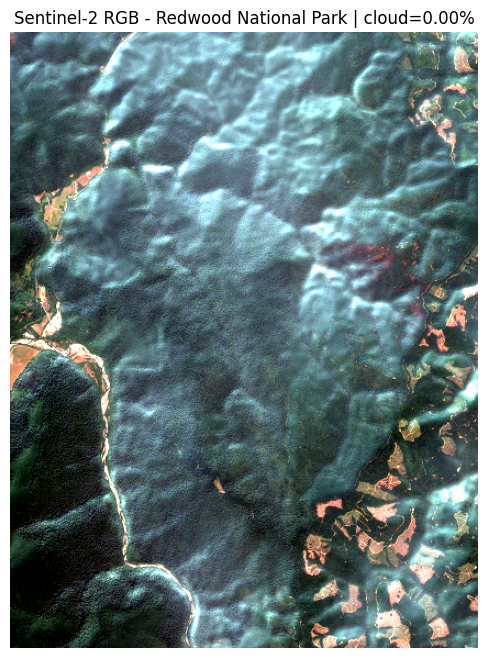

In [8]:
print("Scaled image range:", float(image.min()), float(image.max()))
rgb = rgb_from_bands(image, bands, percentile_stretch=True)
print("RGB display range:", float(rgb.min()), float(rgb.max()))

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title(f"Sentinel-2 RGB - Redwood National Park | cloud={item.properties.get('eo:cloud_cover'):.2f}%")
plt.axis("off");